## Post Processing

In [80]:
from pathlib import Path
from datetime import datetime
import re
import json
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "jupyter_notebooks" else Path.cwd()

# ============================================================================
# UTILITIES & PATH HELPERS
# ============================================================================

def _as_project_path(path_like: str) -> Path:
    """Convert relative paths to project-root-relative paths."""
    p = Path(path_like)
    return p if p.is_absolute() else (PROJECT_ROOT / p)

def _ts_from_name(text: str):
    """Extract datetime (YYYYMMDD_HHMMSS) from filename."""
    m = re.search(r"(\d{8}_\d{6})", text)
    if not m:
        return None
    try:
        return datetime.strptime(m.group(1), "%Y%m%d_%H%M%S")
    except ValueError:
        return None

def _nearest_run_dir(parent: Path, ts: datetime):
    """Find the run directory on the same day with the nearest timestamp."""
    day_prefix = ts.strftime("%Y%m%d")
    run_dirs = sorted(parent.glob(f"cpmg_reopt_run_{day_prefix}_*"))
    if not run_dirs:
        return None

    best = None
    best_dt = None
    for run_dir in run_dirs:
        run_ts = _ts_from_name(run_dir.name)
        if run_ts is None:
            continue
        delta = abs((run_ts - ts).total_seconds())
        if best_dt is None or delta < best_dt:
            best = run_dir
            best_dt = delta
    return best

# ============================================================================
# HDF5 UTILITIES
# ============================================================================

def _collect_datasets(h5f: h5py.File):
    """Recursively collect all datasets from HDF5 file."""
    datasets = {}
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)
    return datasets

def _find_series(datasets: dict, candidate_names):
    """Find first matching dataset by name."""
    for candidate in candidate_names:
        for key, value in datasets.items():
            if Path(key).name == candidate:
                return np.asarray(value)
    return None

def _resolve_chunk_files(path_like: str):
    """Return chunk h5 files for run folders, log files, or direct h5 paths."""
    p = _as_project_path(path_like)

    if p.is_dir():
        files = sorted(p.glob("*_chunk_*.h5"))
        if not files:
            files = sorted(p.glob("*chunk*.h5"))
        return files

    if p.is_file() and p.suffix.lower() == ".log":
        ts = _ts_from_name(p.stem)
        candidates = []
        if ts is not None:
            ts_str = ts.strftime("%Y%m%d_%H%M%S")
            candidates.append(p.parent / f"cpmg_reopt_run_{ts_str}")

        stem_candidate = p.stem.replace("terminal_", "")
        candidates.append(p.parent / stem_candidate)

        for candidate in candidates:
            if candidate.is_dir():
                files = sorted(candidate.glob("*_chunk_*.h5"))
                if files:
                    return files

        # Fallback: use nearest run directory on same day as the log timestamp.
        if ts is not None:
            nearest = _nearest_run_dir(p.parent, ts)
            if nearest is not None:
                files = sorted(nearest.glob("*_chunk_*.h5"))
                if files:
                    print(f"Resolved {p.name} to nearest run folder: {nearest.name}")
                    return files
        return []

    if p.is_file() and p.suffix.lower() in {".h5", ".hdf5"}:
        return [p]

    return []

# ============================================================================
# CPMG LOADING & NORMALIZATION
# ============================================================================

def load_cpmg_run(file_path: str, verbose=True):
    """
    Load CPMG combined h5 file with signal1 and reference1.
    Falls back to chunk averaging if reference1 missing from combined file.
    
    Args:
        file_path: Path to combined CPMG h5 file
        verbose: Print status messages
    
    Returns:
        Tuple of (tau_ns, signal1, reference1) arrays
    """
    file_path = _as_project_path(file_path)
    
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")
    
    # Try to load from combined file
    try:
        with h5py.File(file_path, "r") as h5f:
            datasets = _collect_datasets(h5f)
            
            # Find tau (try multiple names)
            tau = _find_series(datasets, ["tau_ns", "tau_ftns", "tau_tus", "tau_samples"])
            # Find signal1
            signal = _find_series(datasets, ["signal1_cts_s", "signal1"])
            # Find reference1 (NOT signal2)
            reference = _find_series(datasets, ["reference1_cts_s", "reference1"])
        
        if tau is None or signal is None:
            raise KeyError("Missing tau or signal1 in combined file")
        
        # If reference missing, try chunks
        if reference is None:
            if verbose:
                print(f"  Reference1 missing from combined file; loading from chunks...")
            reference = _load_reference_from_chunks(file_path.parent, verbose=False)
            if reference is None:
                raise RuntimeError(f"Could not load reference1 from combined or chunk files")
        
        # Handle tau unit conversion
        tau = np.asarray(tau, dtype=float).ravel()
        if tau.min() < 100:  # Assume samples if span is small
            tau_ns = tau * 0.20345052083333334
        else:
            tau_ns = tau
        
        signal = np.asarray(signal, dtype=float).ravel()
        reference = np.asarray(reference, dtype=float).ravel()
        
        if verbose:
            print(f"  ✓ Loaded from {file_path.name}")
        
        return tau_ns, signal, reference
        
    except Exception as e:
        if verbose:
            print(f"  Error loading {file_path.name}: {e}")
        raise

def _load_reference_from_chunks(run_dir: Path, verbose=True):
    """
    Load and average reference1 from chunk files in a run directory.
    Weights by 'reps' attribute.
    """
    run_dir = _as_project_path(run_dir)
    chunk_files = _resolve_chunk_files(str(run_dir))
    
    if not chunk_files:
        return None
    
    ref_acc = None
    weight_acc = 0.0
    
    for chunk_file in chunk_files:
        try:
            with h5py.File(chunk_file, "r") as h5f:
                datasets = _collect_datasets(h5f)
                
                ref = _find_series(datasets, ["reference1_cts_s", "reference1"])
                if ref is None:
                    continue
                
                ref = np.asarray(ref, dtype=float).ravel()
                
                # Get reps weight
                reps = 1.0
                if "experiment" in h5f and hasattr(h5f["experiment"], "attrs"):
                    try:
                        reps = float(h5f["experiment"].attrs.get("reps", 1.0))
                    except (TypeError, ValueError):
                        reps = 1.0
                
                if ref_acc is None:
                    ref_acc = np.zeros_like(ref, dtype=float)
                
                if ref_acc.shape == ref.shape:
                    ref_acc += reps * ref
                    weight_acc += reps
        except Exception:
            continue
    
    if ref_acc is not None and weight_acc > 0:
        return ref_acc / weight_acc
    
    return None

def normalize_across_runs(cpmg_data_dict, window=40, center=0.8507, amplitude=0.1474):
    """
    Normalize signal1 across runs using per-run rolling reference1 normalization.
    
    Args:
        cpmg_data_dict: Dict with structure {run_name: {"tau_ns": array, "signal": array, "reference": array}}
        window: Rolling window size (nearest points)
        center: Normalization center parameter
        amplitude: Normalization amplitude parameter
    
    Returns:
        Tuple of (normalized_dict, combined_dataframe)
        - normalized_dict: {run_name: {"tau_us": array, "signal_norm": array}}
        - combined_dataframe: DataFrame with columns [run_name, tau_us, signal_norm]
    """
    normalized = {}
    combined_rows = []
    
    for run_name, data in cpmg_data_dict.items():
        tau_ns = np.asarray(data["tau_ns"], dtype=float).ravel()
        signal = np.asarray(data["signal"], dtype=float).ravel()
        reference = np.asarray(data["reference"], dtype=float).ravel()
        
        # Convert tau to microseconds
        tau_us = tau_ns / 1e3
        
        # Rolling window normalization
        ref_rolling = _rolling_mean(reference, window)
        signal_norm = signal / np.clip(ref_rolling, 1e-12, None)
        
        # Map to 0-state population: (normalized - center) / (amplitude * 2) + 0.5
        signal_norm = (signal_norm - center) / (amplitude * 2.0) + 0.5
        
        normalized[run_name] = {
            "tau_us": tau_us,
            "signal_norm": signal_norm,
        }
        
        # Add to combined dataframe
        for idx, (t, s) in enumerate(zip(tau_us, signal_norm)):
            combined_rows.append({
                "run_name": run_name,
                "tau_us": t,
                "signal_norm": s,
            })
    
    combined_df = pd.DataFrame(combined_rows)
    return normalized, combined_df

def _rolling_mean(arr, window):
    """Centered rolling mean using nearest points in index space."""
    arr = np.asarray(arr, dtype=float).ravel()
    n = len(arr)
    if n == 0:
        return arr
    
    w = max(1, int(window))
    left = w // 2
    right = w - left
    
    out = np.empty(n, dtype=float)
    for i in range(n):
        lo = max(0, i - left)
        hi = min(n, i + right)
        out[i] = np.mean(arr[lo:hi])
    
    return out

In [129]:
%matplotlib widget

In [130]:
# ============================================================================
# METADATA EXTRACTION
# ============================================================================

def extract_metadata(file_path: str, verbose=True):
    """
    Extract metadata from any HDF5 file (chunk or combined).
    Returns: dict with keys like n_cpmg, mw_pi2_ftns, mw_pi2_ftsamp, etc.
    """
    file_path = _as_project_path(file_path)
    metadata = {}
    
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")
    
    try:
        with h5py.File(file_path, "r") as h5f:
            # Check /experiment group and attributes
            if "experiment" in h5f:
                exp = h5f["experiment"]
                if hasattr(exp, 'attrs'):
                    for key in exp.attrs:
                        try:
                            val = exp.attrs[key]
                            if isinstance(val, bytes):
                                val = val.decode('utf-8')
                            metadata[key] = val
                        except Exception:
                            pass
            
            # If no metadata found in /experiment, check root attributes
            if not metadata and hasattr(h5f, 'attrs'):
                for key in h5f.attrs:
                    try:
                        val = h5f.attrs[key]
                        if isinstance(val, bytes):
                            val = val.decode('utf-8')
                        metadata[key] = val
                    except Exception:
                        pass
    except Exception as e:
        if verbose:
            print(f"Error reading metadata from {file_path.name}: {e}")
    
    if verbose and metadata:
        print(f"Metadata from {file_path.name}:")
        for k, v in metadata.items():
            print(f"  {k}: {v}")
    
    return metadata


# Test: Extract metadata from a file
test_file = r"data\cpmg_reopt\cpmg_reopt_run_20260329_231000\cpmg_xy_fine_res_chunk_20260329_232847.h5"
metadata_example = extract_metadata(test_file)

Metadata from cpmg_xy_fine_res_chunk_20260329_232847.h5:
  adc_channel: 0
  get_reference: False
  laser_gate_pmod: 0
  laser_on_tns: 5999.348958333334
  laser_on_treg: 1843
  laser_on_tus: 5.999348958333334
  laser_readout_offset_tns: 1168.6197916666667
  laser_readout_offset_treg: 359
  laser_readout_offset_tus: 1.1686197916666667
  loop_chunk_reps: 1000
  loop_cycle_index: 0
  loop_pre_chunk_reopt_status: manual_initial
  loop_run_id: 20260329_231000
  loop_target_total_reps: 27000
  loop_total_cycles_planned: 27
  mw_channel: 0
  mw_freg: 1612884651
  mw_gain: 32767
  mw_nqz: 1
  mw_pi2_ftns: 26.85546875
  mw_pi2_ftsamp: 132
  mw_pi2_ftus: 0.02685546875
  mw_to_laser_delay_tns: 553.3854166666667
  mw_to_laser_delay_treg: 170
  mw_to_laser_delay_tus: 0.5533854166666667
  n_cpmg: 32
  nsweep_points: 2561
  pre_init: True
  readout_integration_tns: 680.3385416666667
  readout_integration_treg: 209
  readout_integration_tus: 0.6803385416666667
  readout_reference_start_tns: 5000.0
  re

In [ ]:
# For all my CPMG files, I need to modify the tau value, but only once. I want to deliniate between files i made the modification to and those I didn't. I think I'll save the correct files in a seperate folder but with the same name

# The only change I need to make is to add a small time offset because i previously forgot to correct for it.

# The change consists of extracting this value: mw_pi2_ftsamp from the meta_data


SyntaxError: invalid syntax (2723370604.py, line 3)

In [140]:
# ============================================================================
# CHUNK DATA ANALYSIS
# ============================================================================

def analyze_chunks(folders_or_paths, reference_key="reference1", signal_key="signal1", verbose=True):
    """
    Load and analyze chunk data from one or more run folders/log files.
    
    Args:
        folders_or_paths: str or list of str (run folder, log file, or direct chunk h5)
        reference_key: name of reference dataset (e.g., "reference1", "reference1_cts_s")
        signal_key: name of signal dataset (e.g., "signal1", "signal1_cts_s")
        verbose: print status messages
    
    Returns:
        pandas.DataFrame with columns: source, chunk_file, chunk_index, 
                                      reference1_mean, reference1_std,
                                      signal1_mean, signal1_std
    """
    if isinstance(folders_or_paths, str):
        folders = [folders_or_paths]
    else:
        folders = list(folders_or_paths)
    
    rows = []
    for folder in folders:
        chunk_files = _resolve_chunk_files(folder)
        if not chunk_files:
            if verbose:
                print(f"No chunk files found for: {folder}")
            continue

        for idx, h5_path in enumerate(chunk_files, start=1):
            try:
                with h5py.File(h5_path, "r") as h5f:
                    datasets = _collect_datasets(h5f)
                    ref = _find_series(datasets, [reference_key, reference_key.replace("reference", "signal")])
                    sig = _find_series(datasets, [signal_key, signal_key.replace("signal", "signal")])

                if ref is None or sig is None:
                    if verbose:
                        print(f"Missing {reference_key} or {signal_key} in: {h5_path.name}")
                    continue

                ref = np.asarray(ref, dtype=float).ravel()
                sig = np.asarray(sig, dtype=float).ravel()

                rows.append({
                    "source": str(folder),
                    "chunk_file": h5_path.name,
                    "chunk_index": idx,
                    "reference1_mean": float(np.mean(ref)),
                    "reference1_std": float(np.std(ref, ddof=1)) if ref.size > 1 else 0.0,
                    "signal1_mean": float(np.mean(sig)),
                    "signal1_std": float(np.std(sig, ddof=1)) if sig.size > 1 else 0.0,
                })
            except Exception as e:
                if verbose:
                    print(f"Error processing {h5_path.name}: {e}")
                continue

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No usable chunk data found.")
    
    if verbose:
        print(f"Loaded {len(df)} chunks from {len(folders)} source(s)")
    
    return df


# Example: Analyze chunks from specified folders
folders_to_analyze = [
    r"data\cpmg_reopt\cpmg_reopt_run_20260329_231000",
    r"data\cpmg_reopt\terminal_cpmg_reopt_20260327_191002.log",
]

chunk_df = analyze_chunks(folders_to_analyze, verbose=True)
display(chunk_df[["source", "chunk_file", "reference1_mean", "reference1_std", "signal1_mean", "signal1_std"]].head(10))

Resolved terminal_cpmg_reopt_20260327_191002.log to nearest run folder: cpmg_reopt_run_20260327_191005
Loaded 177 chunks from 2 source(s)


,source,chunk_file,reference1_mean,reference1_std,signal1_mean,signal1_std
0,data\cpmg_reopt\cpmg_reopt_run_20260329_231000,cpmg_xy_fine_res_chunk_20260329_232847.h5,51.573604,7.307915,47.272159,7.282344
1,data\cpmg_reopt\cpmg_reopt_run_20260329_231000,cpmg_xy_fine_res_chunk_20260329_234810.h5,50.180008,7.355324,45.966810,7.347358
2,data\cpmg_reopt\cpmg_reopt_run_20260329_231000,cpmg_xy_fine_res_chunk_20260330_000733.h5,51.060523,7.305756,46.967591,7.235122
3,data\cpmg_reopt\cpmg_reopt_run_20260329_231000,cpmg_xy_fine_res_chunk_20260330_002656.h5,50.493948,7.005415,46.259664,7.139085
4,data\cpmg_reopt\cpmg_reopt_run_20260329_231000,cpmg_xy_fine_res_chunk_20260330_004619.h5,48.846154,7.028830,44.967200,7.201271
5,data\cpmg_reopt\cpmg_reopt_run_20260329_231000,cpmg_xy_fine_res_chunk_20260330_010541.h5,50.468957,7.083150,46.305740,7.230027
6,data\cpmg_reopt\cpmg_reopt_run_20260329_231000,cpmg_xy_fine_res_chunk_20260330_012504.h5,50.414291,7.237582,46.406872,7.246768
7,data\cpmg_reopt\cpmg_reopt_run_20260329_231000,cpmg_xy_fine_res_chunk_20260330_014427.h5,50.589223,7.460884,46.540804,7.415829
8,data\cpmg_reopt\cpmg_reopt_run_20260329_231000,cpmg_xy_fine_res_chunk_20260330_020350.h5,48.888715,6.965240,44.885592,7.114506
9,data\cpmg_reopt\cpmg_reopt_run_20260329_231000,cpmg_xy_fine_res_chunk_20260330_022313.h5,48.002733,6.989361,43.884811,7.052676


=== All chunks ===


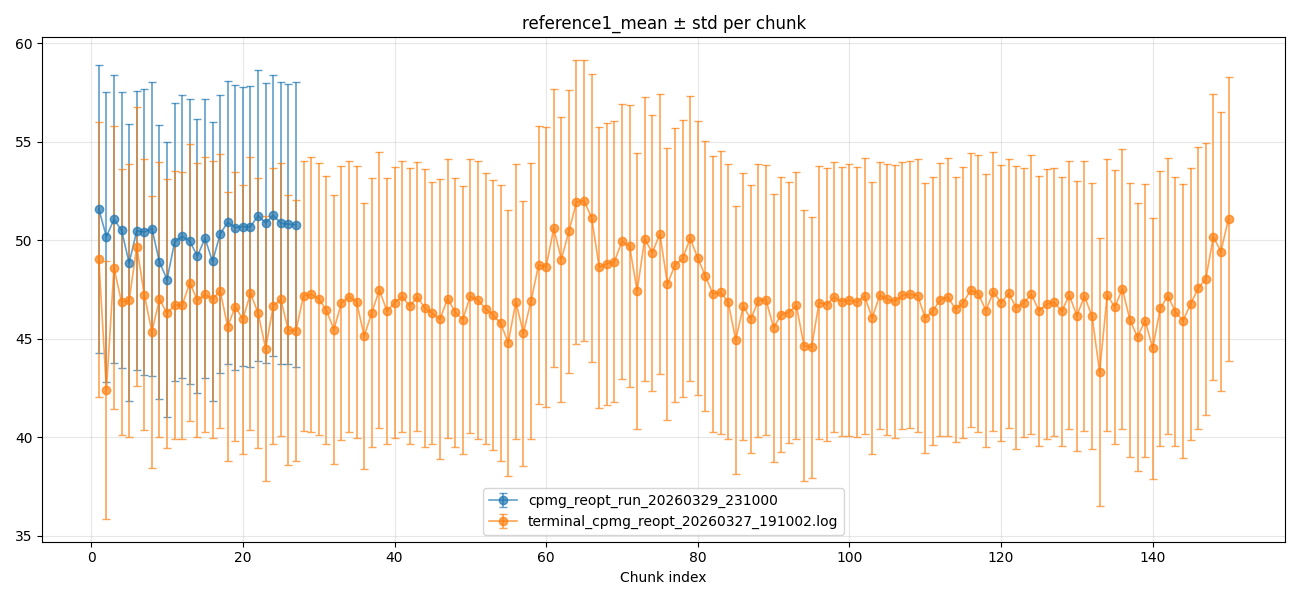


=== Excluding bottom 5% ===
Excluded 9 chunks (bottom 5%)


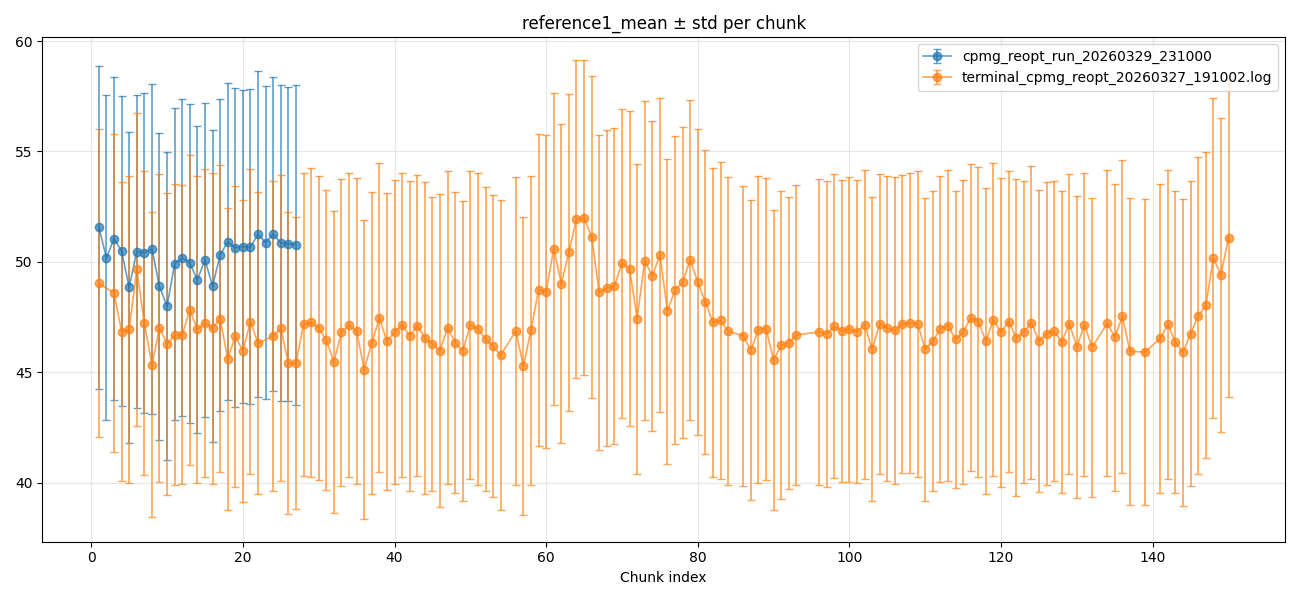


=== Excluding specific threshold ===
Excluded 8 chunks with reference1_mean < 45


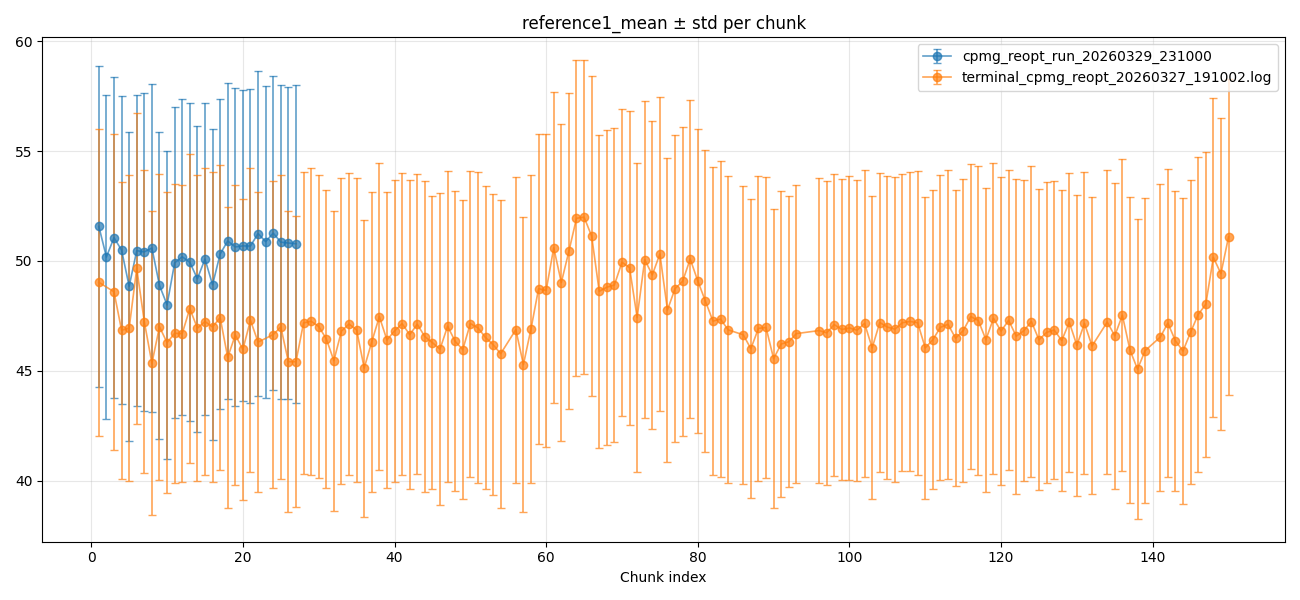

In [132]:
# ============================================================================
# SELECTIVE CHUNK PLOTTING
# ============================================================================

def plot_chunks(df, metric="reference1_mean", exclude_lowest_pct=None, exclude_lowest_counts=None, 
                figsize=(13, 6), separate_sources=False):
    """
    Plot chunk statistics with optional filtering.
    
    Args:
        df: DataFrame from analyze_chunks()
        metric: column to plot ("reference1_mean", "signal1_mean", etc.)
        exclude_lowest_pct: exclude bottom X% of chunks by count (e.g., 5 for bottom 5%)
        exclude_lowest_counts: exclude chunks with count below this threshold
        figsize: figure size
        separate_sources: if True, create subplot per source; else overlay all sources
    """
    plot_df = df.copy()
    
    # Apply filters
    if exclude_lowest_pct is not None:
        threshold = plot_df[metric].quantile(exclude_lowest_pct / 100.0)
        n_before = len(plot_df)
        plot_df = plot_df[plot_df[metric] >= threshold]
        print(f"Excluded {n_before - len(plot_df)} chunks (bottom {exclude_lowest_pct}%)")
    
    if exclude_lowest_counts is not None:
        n_before = len(plot_df)
        plot_df = plot_df[plot_df[metric] >= exclude_lowest_counts]
        print(f"Excluded {n_before - len(plot_df)} chunks with {metric} < {exclude_lowest_counts}")
    
    sources = plot_df["source"].unique()
    
    if separate_sources:
        fig, axes = plt.subplots(1, len(sources), figsize=(figsize[0], figsize[1]), sharey=True)
        if len(sources) == 1:
            axes = [axes]
        
        for ax, src in zip(axes, sources):
            g = plot_df[plot_df["source"] == src].sort_values("chunk_index")
            ax.errorbar(
                g["chunk_index"],
                g[metric],
                yerr=g[metric.replace("_mean", "_std")],
                marker="o", capsize=3, linewidth=1.2, label=Path(src).name,
            )
            ax.set_title(Path(src).name)
            ax.set_xlabel("Chunk index")
            ax.grid(alpha=0.3)
    else:
        fig, ax = plt.subplots(figsize=figsize)
        for src in sources:
            g = plot_df[plot_df["source"] == src].sort_values("chunk_index")
            ax.errorbar(
                g["chunk_index"],
                g[metric],
                yerr=g[metric.replace("_mean", "_std")],
                marker="o", capsize=3, linewidth=1.2, label=Path(src).name, alpha=0.7
            )
        ax.set_xlabel("Chunk index")
        ax.set_title(f"{metric} ± std per chunk")
        ax.grid(alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()


# Example usage: Plot with filtering
# Try different filters:
# 1. Without filtering (all chunks)
print("=== All chunks ===")
plot_chunks(chunk_df, metric="reference1_mean")

# 2. Exclude bottom 5%
print("\n=== Excluding bottom 5% ===")
plot_chunks(chunk_df, metric="reference1_mean", exclude_lowest_pct=5)

# 3. Exclude lowest-count run (for multirun: set threshold)
print("\n=== Excluding specific threshold ===")
plot_chunks(chunk_df, metric="reference1_mean", exclude_lowest_counts=45)

In [133]:
# ============================================================================
# LOAD CPMG RUNS
# ============================================================================

print("Loading CPMG runs...")
cpmg_runs = {
    "run_20260324_222413": r"data\cpmg_reopt\cpmg_reopt_run_20260324_222413\cpmg_xy_fine_res_combined.h5",
    "run_20260326_224519": r"data\cpmg_reopt\cpmg_reopt_run_20260326_224519\cpmg_xy_fine_res_combined.h5",
}

cpmg_data = {}
for run_name, run_path in cpmg_runs.items():
    tau_ns, signal, reference = load_cpmg_run(run_path, verbose=True)
    cpmg_data[run_name] = {
        "tau_ns": tau_ns,
        "signal": signal,
        "reference": reference,
    }
    print(f"  ✓ {run_name}: {len(tau_ns)} points")

print("✓ All runs loaded")

Loading CPMG runs...
  Reference1 missing from combined file; loading from chunks...
  ✓ Loaded from cpmg_xy_fine_res_combined.h5
  ✓ run_20260324_222413: 1121 points
  Reference1 missing from combined file; loading from chunks...
  ✓ Loaded from cpmg_xy_fine_res_combined.h5
  ✓ run_20260326_224519: 801 points
✓ All runs loaded


In [134]:
# Debug: Test BOTH files
files_to_test = [
    (r"data\cpmg_reopt\cpmg_reopt_run_20260324_222413\cpmg_xy_fine_res_combined.h5", "File 1"),
    (r"data\cpmg_reopt\cpmg_reopt_run_20260326_224519\cpmg_xy_fine_res_combined.h5", "File 2"),
]

for path, label in files_to_test:
    print(f"\n{label}: {path}")
    try:
        tau_test, sig_test, ref_test = load_cpmg_run(path, verbose=False)
        print(f"  Shapes: tau={tau_test.shape}, signal={sig_test.shape}, ref={ref_test.shape}")
        print(f"  Ref range: [{ref_test.min():.1f}, {ref_test.max():.1f}]")
    except Exception as e:
        print(f"  ERROR: {e}")


File 1: data\cpmg_reopt\cpmg_reopt_run_20260324_222413\cpmg_xy_fine_res_combined.h5
  Shapes: tau=(1121,), signal=(1121,), ref=(1121,)
  Ref range: [77946.5, 85766.1]

File 2: data\cpmg_reopt\cpmg_reopt_run_20260326_224519\cpmg_xy_fine_res_combined.h5
  Shapes: tau=(801,), signal=(801,), ref=(801,)
  Ref range: [82223.8, 88999.8]


Building chunk-filtered CPMG sweep...
Resolved terminal_cpmg_reopt_20260327_191002.log to nearest run folder: cpmg_reopt_run_20260327_191005


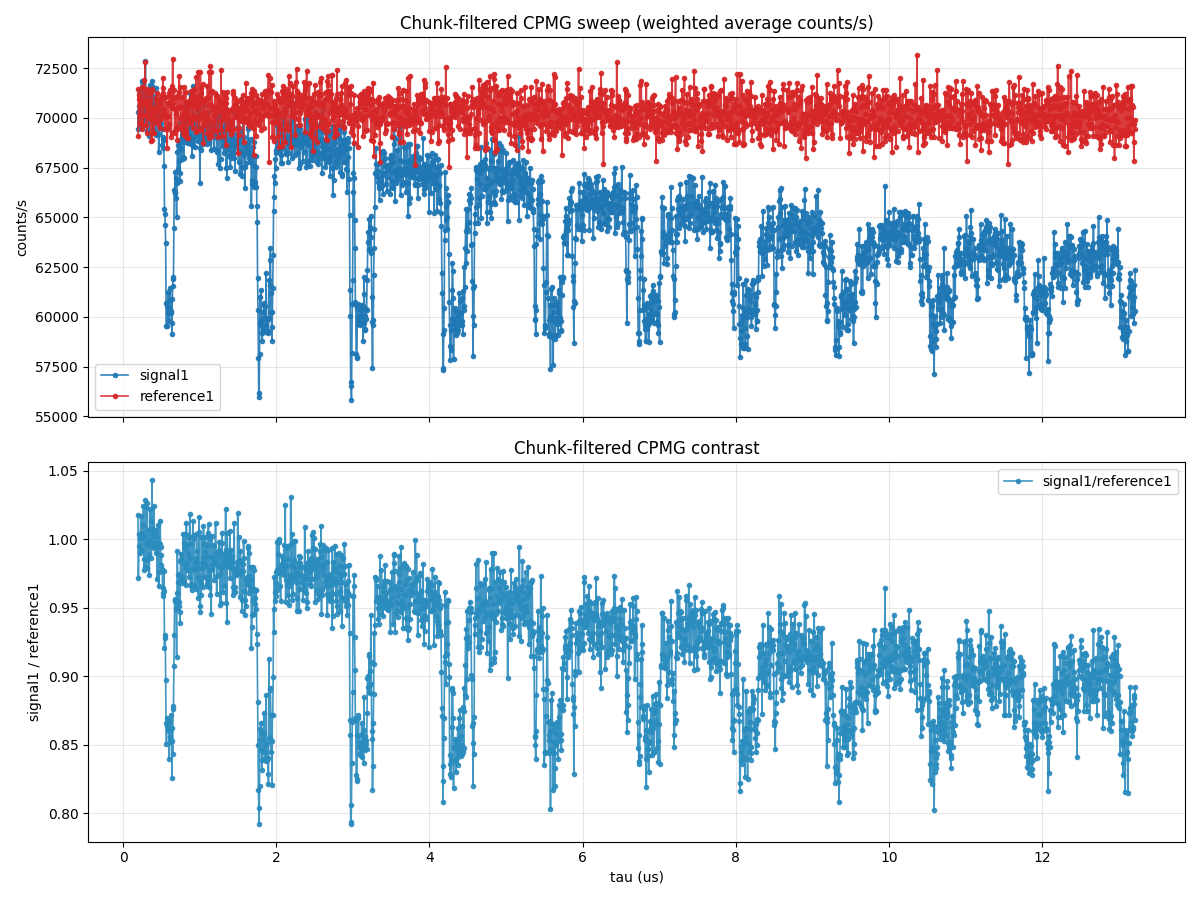

CPMG sweep build summary:
  metric filter: reference1_mean
  chunks selected by metric: 168
  chunks used in sweep: 168
  chunks skipped (missing/mismatch/error): 0
  total weight (sum reps): 168000.0
  aggregation mode: avg_rate


In [135]:
# ============================================================================
# CHUNK-FILTERED CPMG SWEEP (NO MEAN/STD PLOT)
# ============================================================================


def _filter_chunk_df(df, metric="reference1_mean", exclude_lowest_pct=None, exclude_lowest_counts=None, include_sources=None):
    """Filter chunk summary table to choose which chunks to include in sweep construction."""
    out = df.copy()

    if include_sources is not None:
        include_sources = set(include_sources)
        out = out[out["source"].isin(include_sources)]

    if exclude_lowest_pct is not None:
        threshold = out[metric].quantile(exclude_lowest_pct / 100.0)
        out = out[out[metric] >= threshold]

    if exclude_lowest_counts is not None:
        out = out[out[metric] >= exclude_lowest_counts]

    return out.sort_values(["source", "chunk_index"]).reset_index(drop=True)


def _build_selected_chunk_paths(filtered_df):
    """Resolve chunk paths for filtered rows using source + chunk filename."""
    source_cache = {}
    selected_paths = []

    for _, row in filtered_df.iterrows():
        src = str(row["source"])
        chunk_name = str(row["chunk_file"])

        if src not in source_cache:
            source_cache[src] = {p.name: p for p in _resolve_chunk_files(src)}

        p = source_cache[src].get(chunk_name)
        if p is not None:
            selected_paths.append(p)

    return selected_paths


def _aggregate_cpmg_from_chunks(chunk_paths, aggregation="avg_rate"):
    """
    Aggregate chunk traces into a single CPMG sweep.

    aggregation:
      - "avg_rate": weighted average counts/s (weights = reps)
      - "cumulative_counts": cumulative effective counts (sum of counts/s * reps)
    """
    if not chunk_paths:
        raise RuntimeError("No chunk files selected after filtering.")

    tau_ref = None
    sig_acc = None
    ref_acc = None
    w_acc = 0.0
    used = 0
    skipped = 0

    for chunk_file in chunk_paths:
        try:
            with h5py.File(chunk_file, "r") as h5f:
                datasets = _collect_datasets(h5f)
                tau = _find_series(datasets, ["tau_ns", "tau_ftns", "tau_tus", "tau_samples"])
                sig = _find_series(datasets, ["signal1_cts_s", "signal1"])
                ref = _find_series(datasets, ["reference1_cts_s", "reference1"])

                if tau is None or sig is None or ref is None:
                    skipped += 1
                    continue

                tau = np.asarray(tau, dtype=float).ravel()
                sig = np.asarray(sig, dtype=float).ravel()
                ref = np.asarray(ref, dtype=float).ravel()

                if tau.shape != sig.shape or sig.shape != ref.shape:
                    skipped += 1
                    continue

                reps = 1.0
                if "experiment" in h5f and hasattr(h5f["experiment"], "attrs"):
                    try:
                        reps = float(h5f["experiment"].attrs.get("reps", 1.0))
                    except (TypeError, ValueError):
                        reps = 1.0

                if tau_ref is None:
                    tau_ref = tau.copy()
                    sig_acc = np.zeros_like(sig, dtype=float)
                    ref_acc = np.zeros_like(ref, dtype=float)

                if tau_ref.shape != tau.shape or not np.allclose(tau_ref, tau):
                    skipped += 1
                    continue

                sig_acc += reps * sig
                ref_acc += reps * ref
                w_acc += reps
                used += 1

        except Exception:
            skipped += 1

    if tau_ref is None or sig_acc is None or ref_acc is None or used == 0:
        raise RuntimeError("Unable to construct CPMG sweep from selected chunks.")

    if np.nanmax(tau_ref) < 100:
        tau_ns = tau_ref * 0.20345052083333334
    else:
        tau_ns = tau_ref

    if aggregation == "avg_rate":
        signal = sig_acc / np.clip(w_acc, 1e-12, None)
        reference = ref_acc / np.clip(w_acc, 1e-12, None)
        y_label = "counts/s"
        title_suffix = "weighted average counts/s"
    elif aggregation == "cumulative_counts":
        signal = sig_acc
        reference = ref_acc
        y_label = "cumulative effective counts"
        title_suffix = "cumulative (weighted by reps)"
    else:
        raise ValueError("aggregation must be 'avg_rate' or 'cumulative_counts'")

    ratio = signal / np.clip(reference, 1e-12, None)

    summary = {
        "chunks_selected": len(chunk_paths),
        "chunks_used": used,
        "chunks_skipped": skipped,
        "weight_total": float(w_acc),
        "mode": aggregation,
        "title_suffix": title_suffix,
        "y_label": y_label,
    }

    return tau_ns, signal, reference, ratio, summary


def plot_cpmg_sweep_from_chunks(
    df,
    metric="reference1_mean",
    exclude_lowest_pct=5,
    exclude_lowest_counts=None,
    include_sources=None,
    aggregation="avg_rate",
    figsize=(12, 9),
):
    """
    Build and plot a CPMG sweep from chunk files selected by chunk-level metrics.
    Returns a dict containing the processed sweep arrays and summary info.
    """
    filtered = _filter_chunk_df(
        df,
        metric=metric,
        exclude_lowest_pct=exclude_lowest_pct,
        exclude_lowest_counts=exclude_lowest_counts,
        include_sources=include_sources,
    )

    selected_paths = _build_selected_chunk_paths(filtered)
    tau_ns, signal, reference, ratio, info = _aggregate_cpmg_from_chunks(selected_paths, aggregation=aggregation)

    tau_us = tau_ns / 1e3

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    # Keep similar color convention as CPMG sequencing section.
    axes[0].plot(tau_us, signal, "o-", lw=1.2, ms=3.0, alpha=0.9, color="#1f77b4", label="signal1")
    axes[0].plot(tau_us, reference, "o-", lw=1.2, ms=3.0, alpha=0.9, color="#d62728", label="reference1")
    axes[0].set_ylabel(info["y_label"])
    axes[0].set_title(f"Chunk-filtered CPMG sweep ({info['title_suffix']})")
    axes[0].grid(alpha=0.3)
    axes[0].legend(loc="best", fontsize=10)

    axes[1].plot(tau_us, ratio, "o-", lw=1.2, ms=3.0, alpha=0.9, color="#2b8cbe", label="signal1/reference1")
    axes[1].set_xlabel("tau (us)")
    axes[1].set_ylabel("signal1 / reference1")
    axes[1].set_title("Chunk-filtered CPMG contrast")
    axes[1].grid(alpha=0.3)
    axes[1].legend(loc="best", fontsize=10)

    plt.tight_layout()
    plt.show()

    print("CPMG sweep build summary:")
    print(f"  metric filter: {metric}")
    print(f"  chunks selected by metric: {info['chunks_selected']}")
    print(f"  chunks used in sweep: {info['chunks_used']}")
    print(f"  chunks skipped (missing/mismatch/error): {info['chunks_skipped']}")
    print(f"  total weight (sum reps): {info['weight_total']:.1f}")
    print(f"  aggregation mode: {info['mode']}")

    return {
        "tau_ns": np.asarray(tau_ns, dtype=float).ravel(),
        "signal": np.asarray(signal, dtype=float).ravel(),
        "reference": np.asarray(reference, dtype=float).ravel(),
        "contrast": np.asarray(ratio, dtype=float).ravel(),
        "summary": info,
    }


# Example usage for Cell 8:
# - Set aggregation="avg_rate" for averaged counts/s
# - Set aggregation="cumulative_counts" for cumulative effective counts
print("Building chunk-filtered CPMG sweep...")
chunk_sweep_data = plot_cpmg_sweep_from_chunks(
    chunk_df,
    metric="reference1_mean",
    exclude_lowest_pct=5,
    exclude_lowest_counts=None,
    include_sources=None,
    aggregation="avg_rate",
)

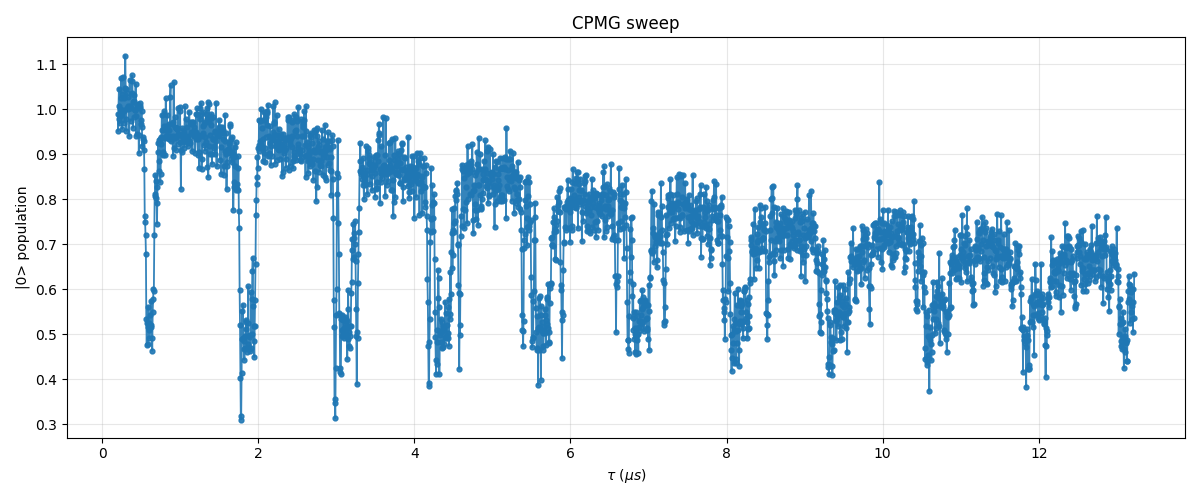

Cell 9 normalization summary:
  points: 2561
  range: [0.3100, 1.1189]
  mean:  0.7286


In [143]:
# ============================================================================
# NORMALIZE CHUNK-FILTERED CPMG SWEEP FROM CELL 8
# ============================================================================

# Requires chunk_sweep_data generated in Cell 8.
if "chunk_sweep_data" not in globals():
    raise RuntimeError("Run Cell 8 first to generate chunk_sweep_data.")

# Reuse the same normalization utility/method used in the normalization section.
cpmg_data_cell9 = {
    "chunk_filtered_sweep": {
        "tau_ns": np.asarray(chunk_sweep_data["tau_ns"], dtype=float).ravel(),
        "signal": np.asarray(chunk_sweep_data["signal"], dtype=float).ravel(),
        "reference": np.asarray(chunk_sweep_data["reference"], dtype=float).ravel(),
    }
}

normalized_cell9, run_df_cell9 = normalize_across_runs(
    cpmg_data_cell9,
    window=40,
    center=0.8507,
    amplitude=0.1474,
)

# Plot normalized data from Cell 8 processing.
norm_data = normalized_cell9["chunk_filtered_sweep"]
tau_us = norm_data["tau_us"] + (28 / (4915.2e6))*1e6
signal_norm = norm_data["signal_norm"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    tau_us,
    signal_norm,
    "o-",
    lw=1.3,
    ms=3.5,
    alpha=0.9,
    color="#1f77b4",
    label="chunk-filtered normalized",
)
ax.set_xlabel(r"$\tau$ ($\mu s$)")
ax.set_ylabel("|0> population")
ax.set_title("CPMG sweep")
ax.grid(alpha=0.3)
# ax.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.show()

print("Cell 9 normalization summary:")
print(f"  points: {len(signal_norm)}")
print(f"  range: [{np.nanmin(signal_norm):.4f}, {np.nanmax(signal_norm):.4f}]")
print(f"  mean:  {np.nanmean(signal_norm):.4f}")

In [ ]:
import pandas as pd

# Create a simple CSV file with tau_us and signal_norm from the current data

# Use the normalized data from the current cell
tau_us_data = np.asarray(tau_us, dtype=float).ravel()
signal_norm_data = np.asarray(signal_norm, dtype=float).ravel()

# Create a DataFrame
cpmg_export_df = pd.DataFrame({
    'tau_us': tau_us_data,
    'signal_norm': signal_norm_data,
})

# Save to CSV
export_filename = "cpmg_data_normalized.csv"
cpmg_export_df.to_csv(export_filename, index=False)
print(f"✓ Exported CPMG data to {export_filename}")
print(f"  Rows: {len(cpmg_export_df)}")
print(f"  Columns: {list(cpmg_export_df.columns)}")

## CPMG Comparison

In [110]:
# ============================================================================
# CPMG COMPARISON INPUT RUNS (Cell 10)
# ============================================================================

# Run directories requested for comparison.
comparison_run_dirs = [    
    r"data\cpmg_reopt\cpmg_reopt_run_20260324_222413",
    r"data\cpmg_reopt\cpmg_reopt_run_20260325_162152",
    r"data\cpmg_reopt\cpmg_reopt_run_20260326_170654",
]


def _resolve_combined_h5(run_path_like: str) -> Path:
    """Accept run dir or file path and return a combined .h5 path."""
    p = _as_project_path(run_path_like)

    if p.is_file() and p.suffix.lower() in {".h5", ".hdf5"}:
        return p

    if p.is_dir():
        preferred = p / "cpmg_xy_fine_res_combined.h5"
        if preferred.exists():
            return preferred

        candidates = sorted(p.glob("*combined*.h5"))
        if candidates:
            return candidates[0]

    raise FileNotFoundError(f"Could not resolve combined h5 for: {run_path_like}")


# Build run_data used by Cell 11.
run_data = {}
for run_dir in comparison_run_dirs:
    combined_h5 = _resolve_combined_h5(run_dir)
    run_name = combined_h5.parent.name

    tau_ns, signal, reference = load_cpmg_run(str(combined_h5), verbose=False)
    contrast = signal / np.clip(reference, 1e-12, None)

    n_cpmg = None
    try:
        chunk_files = _resolve_chunk_files(str(combined_h5.parent))
        if chunk_files:
            with h5py.File(chunk_files[0], "r") as h5f:
                if "experiment" in h5f and "n_cpmg" in h5f["experiment"].attrs:
                    n_cpmg = int(h5f["experiment"].attrs["n_cpmg"])
    except Exception:
        pass

    run_data[run_name] = {
        "tau_ns": np.asarray(tau_ns, dtype=float).ravel(),
        "signal": np.asarray(signal, dtype=float).ravel(),
        "reference": np.asarray(reference, dtype=float).ravel(),
        "contrast": np.asarray(contrast, dtype=float).ravel(),
        "path": str(combined_h5),
        "metadata": {"n_cpmg": n_cpmg} if n_cpmg is not None else {},
    }

    print(f"Loaded {run_name}: {combined_h5}")

print(f"Prepared run_data for {len(run_data)} runs")

Loaded cpmg_reopt_run_20260324_222413: c:\Users\QT3 User Facility\Documents\qick-dawg\data\cpmg_reopt\cpmg_reopt_run_20260324_222413\cpmg_xy_fine_res_combined.h5
Loaded cpmg_reopt_run_20260325_162152: c:\Users\QT3 User Facility\Documents\qick-dawg\data\cpmg_reopt\cpmg_reopt_run_20260325_162152\cpmg_xy_fine_res_combined.h5
Loaded cpmg_reopt_run_20260326_170654: c:\Users\QT3 User Facility\Documents\qick-dawg\data\cpmg_reopt\cpmg_reopt_run_20260326_170654\cpmg_xy_fine_res_combined.h5
Prepared run_data for 3 runs


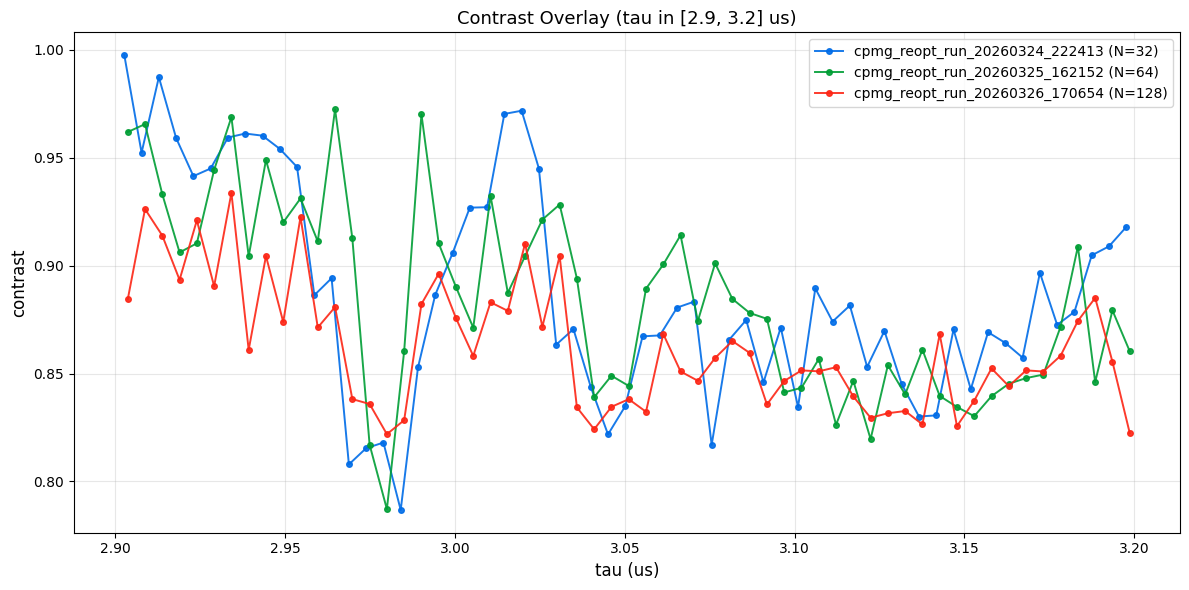


cpmg_reopt_run_20260324_222413:
  59 points in masked region, contrast range: [0.7868, 0.9976]
  N_CPMG = 32

cpmg_reopt_run_20260325_162152:
  59 points in masked region, contrast range: [0.7871, 0.9725]
  N_CPMG = 64

cpmg_reopt_run_20260326_170654:
  59 points in masked region, contrast range: [0.8219, 0.9337]
  N_CPMG = 128


In [112]:
import matplotlib.pyplot as plt
import numpy as np

# Requires run_data produced by Cell 10.
if "run_data" not in globals():
    raise RuntimeError("Run Cell 10 first to prepare run_data.")

# Apply mask for 2.9-3.2 us region.
mask_min_us = 2.9
mask_max_us = 3.2

fig, ax = plt.subplots(figsize=(12, 6))

# High-contrast palette for small comparisons, fallback for larger sets.
n_runs = max(1, len(run_data))
high_contrast = ["#006CE7", "#009E35", "#FC2515", "#891A97", "#E69F00", "#000000"]
if n_runs <= len(high_contrast):
    colors = high_contrast[:n_runs]
else:
    colors = plt.cm.tab10(np.linspace(0, 1, n_runs))

for idx, (run_name, data) in enumerate(run_data.items()):
    x = np.asarray(data["tau_ns"], dtype=float).reshape(-1) / 1e3
    y_con = np.asarray(data["contrast"], dtype=float).reshape(-1)

    metadata = data.get("metadata", {})
    n_cpmg = metadata.get("n_cpmg")
    label = f"{run_name} (N={n_cpmg})" if n_cpmg is not None else run_name

    mask = (x >= mask_min_us) & (x <= mask_max_us)
    x_masked = x[mask]
    y_con_masked = y_con[mask]

    if x_masked.size == 0:
        print(f"{run_name}: no points in mask [{mask_min_us}, {mask_max_us}] us")
        continue

    ax.plot(
        x_masked,
        y_con_masked,
        "o-",
        lw=1.4,
        ms=4.0,
        label=label,
        color=colors[idx],
        alpha=0.9,
    )

ax.set_xlabel("tau (us)", fontsize=12)
ax.set_ylabel("contrast", fontsize=12)
ax.set_title(f"Contrast Overlay (tau in [{mask_min_us}, {mask_max_us}] us)", fontsize=13)
ax.grid(alpha=0.3)
ax.legend(fontsize=10, loc="best")
plt.tight_layout()
plt.show()

# Print summary including extracted metadata.
for run_name, data in run_data.items():
    x = np.asarray(data["tau_ns"], dtype=float).reshape(-1) / 1e3
    y_con = np.asarray(data["contrast"], dtype=float).reshape(-1)
    mask = (x >= mask_min_us) & (x <= mask_max_us)

    metadata = data.get("metadata", {})
    n_cpmg = metadata.get("n_cpmg")

    print(f"\n{run_name}:")
    if np.any(mask):
        print(f"  {np.sum(mask)} points in masked region, contrast range: [{y_con[mask].min():.4f}, {y_con[mask].max():.4f}]")
    else:
        print("  No points in masked region")
    if n_cpmg is not None:
        print(f"  N_CPMG = {n_cpmg}")

## CPMG sequencing

Loaded run_20260324_222413: 1121 points
Loaded run_20260326_224519: 801 points


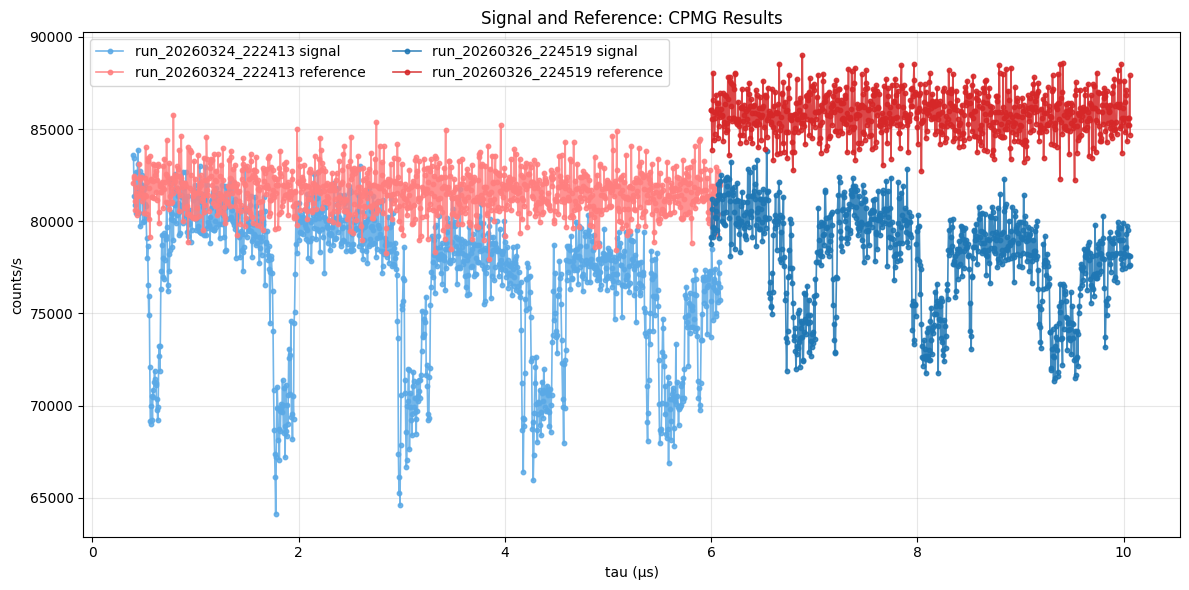

In [ ]:
# ============================================================================
# CPMG SEQUENCING: Load and plot signal & reference
# ============================================================================

cpmg_seq_runs = {
    "run_20260324_222413": r"data\cpmg_reopt\cpmg_reopt_run_20260324_222413\cpmg_xy_fine_res_combined.h5",
    "run_20260326_224519": r"data\cpmg_reopt\cpmg_reopt_run_20260326_224519\cpmg_xy_fine_res_combined.h5",
}

run_data_seq = {}
for run_name, run_path in cpmg_seq_runs.items():
    tau_ns, signal, reference = load_cpmg_run(run_path, verbose=False)
    
    # Try to extract n_cpmg
    n_cpmg = None
    try:
        file_path = _as_project_path(run_path)
        chunk_files = _resolve_chunk_files(str(file_path.parent))
        if chunk_files:
            with h5py.File(chunk_files[0], "r") as h5f:
                if "experiment" in h5f and "n_cpmg" in h5f["experiment"].attrs:
                    n_cpmg = int(h5f["experiment"].attrs["n_cpmg"])
    except Exception:
        pass
    
    run_data_seq[run_name] = {
        "tau_ns": tau_ns,
        "signal": signal,
        "reference": reference,
        "n_cpmg": n_cpmg,
    }
    print(f"Loaded {run_name}: {len(tau_ns)} points")

# Overlay signal1 and reference1 in counts/s
fig, ax = plt.subplots(figsize=(12, 6))

signal_colors = ["#5aa9e6", "#1f77b4"]
reference_colors = ["#ff7f7f", "#d62728"]

for idx, (run_name, data) in enumerate(run_data_seq.items()):
    x_us = data["tau_ns"] / 1e3
    y_sig = data["signal"]
    y_ref = data["reference"]
    
    ax.plot(
        x_us,
        y_sig,
        "o-",
        lw=1.2,
        ms=3.2,
        alpha=0.85,
        color=signal_colors[idx % len(signal_colors)],
        label=f"{run_name} signal",
    )
    
    ax.plot(
        x_us,
        y_ref,
        "o-",
        lw=1.2,
        ms=3.2,
        alpha=0.85,
        color=reference_colors[idx % len(reference_colors)],
        label=f"{run_name} reference",
    )

ax.set_xlabel("tau (µs)")
ax.set_ylabel("counts/s")
ax.set_title("Signal and Reference: CPMG Results")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=10, ncol=2)
plt.tight_layout()
plt.show()

Normalizing CPMG runs...


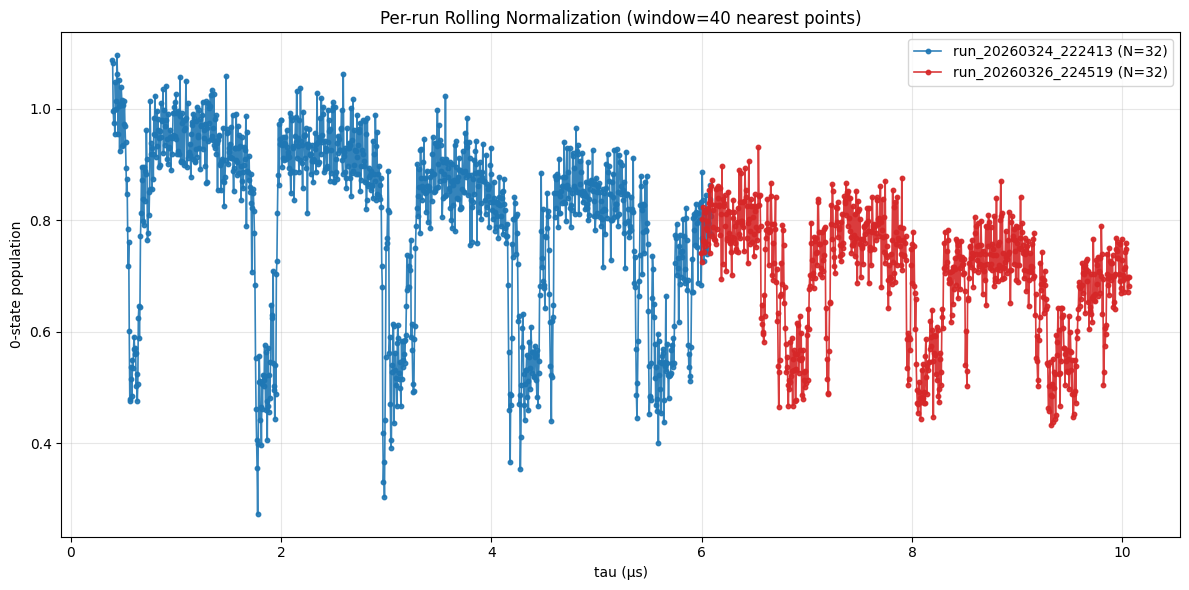


Normalization Summary:
  run_20260324_222413: range [0.2731, 1.0961], mean=0.8080
  run_20260326_224519: range [0.4317, 0.9309], mean=0.6988

✓ Exported normalized CPMG to cpmg_normalized_combined.csv


In [ ]:
# ============================================================================
# NORMALIZATION: Per-run rolling window normalization
# ============================================================================

# Requires run_data_seq from the previous cell
if "run_data_seq" not in globals():
    raise RuntimeError("Run the previous CPMG sequencing cell first to load run_data_seq.")

# Convert run_data_seq structure to cpmg_data_dict format
cpmg_data_for_norm = {}
for run_name, data in run_data_seq.items():
    cpmg_data_for_norm[run_name] = {
        "tau_ns": data["tau_ns"],
        "signal": data["signal"],
        "reference": data["reference"],
    }

# Normalize using shared utilities
print("Normalizing CPMG runs...")
normalized, run_df = normalize_across_runs(cpmg_data_for_norm, window=40, center=0.8507, amplitude=0.1474)

# Plot normalized overlay
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#1f77b4", "#d62728"]

for idx, (run_name, data) in enumerate(normalized.items()):
    n_cpmg = run_data_seq[run_name].get("n_cpmg")
    label = run_name if n_cpmg is None else f"{run_name} (N={n_cpmg})"
    
    ax.plot(
        data["tau_us"],
        data["signal_norm"],
        "o-",
        lw=1.2,
        ms=3.2,
        alpha=0.9,
        color=colors[idx % len(colors)],
        label=label,
    )

ax.set_xlabel("tau (µs)")
ax.set_ylabel("0-state population")
ax.set_title(f"Per-run Rolling Normalization (window=40 nearest points)")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.show()

# Print summary
print("\nNormalization Summary:")
for run_name, data in normalized.items():
    y = data["signal_norm"]
    print(f"  {run_name}: range [{y.min():.4f}, {y.max():.4f}], mean={y.mean():.4f}")

# Export to CSV
csv_filename = "cpmg_normalized_combined.csv"
run_df.to_csv(csv_filename, index=False)
print(f"\n✓ Exported normalized CPMG to {csv_filename}")

In [ ]:
csv_filename = f"minion_Do_combined_runs_signal_normalized.csv"
run_df.to_csv(csv_filename, index=False)
print(f"Exported {run_name} to {csv_filename}")

## Hahn Echo

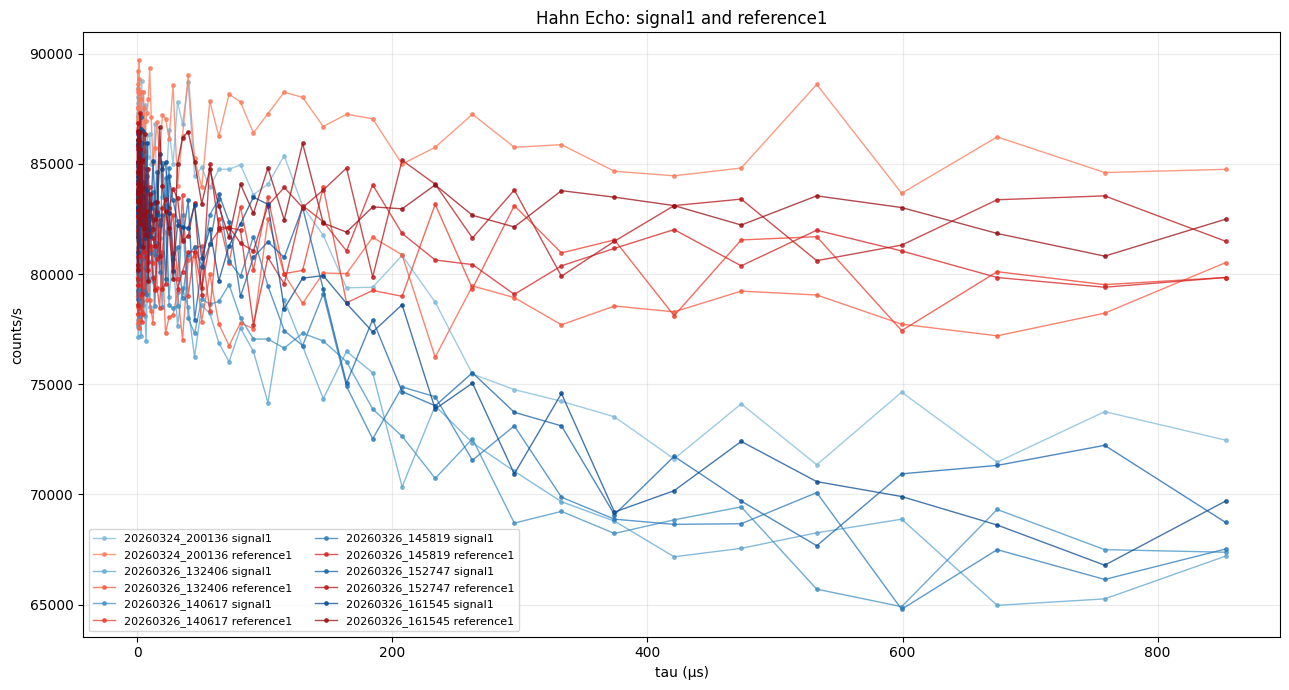

In [ ]:
# ============================================================================
# HAHN ECHO: Load and plot across multiple files
# ============================================================================

HAHN_FILES = [
    r"data\hahn_echo\hahn_echo_fine_res_20260324_200136.h5",
    r"data\hahn_echo\hahn_echo_fine_res_20260326_132406.h5",
    r"data\hahn_echo\hahn_echo_fine_res_20260326_140617.h5",
    r"data\hahn_echo\hahn_echo_fine_res_20260326_145819.h5",
    r"data\hahn_echo\hahn_echo_fine_res_20260326_152747.h5",
    r"data\hahn_echo\hahn_echo_fine_res_20260326_161545.h5",
]

def _load_hahn_echo_file(file_path):
    """Load signal1 and reference1 from a Hahn echo file."""
    file_path = _as_project_path(file_path)
    
    with h5py.File(file_path, "r") as h5f:
        datasets = _collect_datasets(h5f)
        
        tau = _find_series(datasets, ["tau_ns", "tau_ftns", "tau_tus", "tau_samples"])
        signal = _find_series(datasets, ["signal1_cts_s", "signal1"])
        reference = _find_series(datasets, ["reference1_cts_s", "reference1"])
    
    if tau is None or signal is None or reference is None:
        raise KeyError(f"Missing required datasets in {file_path.name}")
    
    tau = np.asarray(tau, dtype=float).ravel()
    if tau.min() < 100:
        tau_ns = tau * 0.20345052083333334
    else:
        tau_ns = tau
    
    return tau_ns, np.asarray(signal, dtype=float).ravel(), np.asarray(reference, dtype=float).ravel()

# Load all files
fig, ax = plt.subplots(figsize=(13, 7))

signal_cmap = plt.cm.Blues(np.linspace(0.45, 0.9, len(HAHN_FILES)))
ref_cmap = plt.cm.Reds(np.linspace(0.45, 0.9, len(HAHN_FILES)))

for idx, file_path in enumerate(HAHN_FILES):
    tau_ns, signal1, reference1 = _load_hahn_echo_file(file_path)
    tau_us = tau_ns / 1e3
    
    file_path = _as_project_path(file_path)
    short_name = file_path.stem.replace("hahn_echo_fine_res_", "")
    
    ax.plot(
        tau_us,
        signal1,
        "o-",
        lw=1.0,
        ms=2.5,
        alpha=0.75,
        color=signal_cmap[idx],
        label=f"{short_name} signal1",
    )
    
    ax.plot(
        tau_us,
        reference1,
        "o-",
        lw=1.0,
        ms=2.5,
        alpha=0.75,
        color=ref_cmap[idx],
        label=f"{short_name} reference1",
    )

ax.set_xlabel("tau (µs)")
ax.set_ylabel("counts/s")
ax.set_title("Hahn Echo: signal1 and reference1")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Requires variables/functions from the cell above.
if "HAHN_FILES" not in globals() or "PROJECT_ROOT" not in globals() or "load_h5_series" not in globals():
    raise RuntimeError("Run the previous Hahn-echo plotting cell first.")

# Increase influence of long-tau points to reduce tail underfitting.
TAIL_WEIGHT_MAX = 6.0  # relative weight at largest tau (1.0 at smallest tau)


def _exp_decay_t2(tau_us_arr, amplitude, t2_us, offset):
    """Same exponential model used in experiments/hahn_echo.py."""
    tau_us_arr = np.asarray(tau_us_arr, dtype=float)
    safe_t2 = np.clip(float(t2_us), 1e-9, None)
    return offset + amplitude * np.exp(-2.0 * np.clip(tau_us_arr, 0.0, None) / safe_t2)


def _fit_t2_signal1_weighted(x_us, y_signal, tail_weight_max=TAIL_WEIGHT_MAX):
    """Weighted fit: emphasize larger tau points (sparser region)."""
    x_us = np.asarray(x_us, dtype=float).reshape(-1)
    y = np.asarray(y_signal, dtype=float).reshape(-1)

    finite = np.isfinite(x_us) & np.isfinite(y)
    x_us = x_us[finite]
    y = y[finite]
    if len(x_us) < 5:
        return None

    order = np.argsort(x_us)
    x_us = x_us[order]
    y = y[order]

    span = float(np.max(x_us) - np.min(x_us))
    if span <= 0:
        return None

    y_lo, y_hi = float(np.min(y)), float(np.max(y))
    y_range = max(y_hi - y_lo, float(np.std(y)) * 2.0, 1e-6)

    p0 = [
        float(y[0] - y[-1]),
        max(span / 2.0, 1e-3),
        float(y[-1]),
    ]
    bounds = (
        [-5.0 * y_range, max(span / 500.0, 1e-3), y_lo - y_range],
        [5.0 * y_range, max(span * 20.0, 10.0), y_hi + y_range],
    )

    # Monotonic weight ramp from short tau -> long tau.
    x_norm = (x_us - np.min(x_us)) / max(span, 1e-12)
    weights = 1.0 + (float(tail_weight_max) - 1.0) * x_norm
    # curve_fit uses residual/sigma, so sigma is inverse to desired weight.
    sigma = 1.0 / np.clip(weights, 1e-12, None)

    try:
        params, cov = curve_fit(
            _exp_decay_t2,
            x_us,
            y,
            p0=p0,
            bounds=bounds,
            sigma=sigma,
            absolute_sigma=False,
            maxfev=60000,
        )
        fit_x = np.linspace(float(np.min(x_us)), float(np.max(x_us)), max(500, len(x_us) * 20))
        fit_sigma = np.sqrt(np.diag(cov)) if cov is not None else np.full(len(params), np.nan)
        return {
            "params": params,
            "sigma": fit_sigma,
            "fit_x": fit_x,
            "fit_y": _exp_decay_t2(fit_x, *params),
            "t2_us": float(params[1]),
            "t2_sigma_us": float(fit_sigma[1]) if len(fit_sigma) > 1 else np.nan,
            "weights": weights,
            "x_sorted": x_us,
            "y_sorted": y,
        }
    except (RuntimeError, ValueError):
        return None


# Load all files and align onto a common tau axis.
series = []
for rel_path in HAHN_FILES:
    file_path = PROJECT_ROOT / Path(rel_path)
    tau_ns, signal1, reference1, _ = load_h5_series(file_path)
    tau_us = np.asarray(tau_ns, dtype=float).reshape(-1) / 1e3
    series.append((file_path.name, tau_us, np.asarray(signal1, dtype=float), np.asarray(reference1, dtype=float)))

if len(series) == 0:
    raise RuntimeError("No Hahn echo files were loaded.")

# Use the first file tau grid as reference; interpolate others if needed.
ref_tau = series[0][1]
aligned_signal = []
aligned_reference = []

for name, tau_us, signal1, reference1 in series:
    if len(tau_us) == len(ref_tau) and np.allclose(tau_us, ref_tau):
        aligned_signal.append(signal1)
        aligned_reference.append(reference1)
    else:
        # Interpolate to common tau for averaging.
        s_interp = np.interp(ref_tau, tau_us, signal1)
        r_interp = np.interp(ref_tau, tau_us, reference1)
        aligned_signal.append(s_interp)
        aligned_reference.append(r_interp)

aligned_signal = np.asarray(aligned_signal, dtype=float)
aligned_reference = np.asarray(aligned_reference, dtype=float)

avg_signal1 = np.mean(aligned_signal, axis=0)
avg_reference1 = np.mean(aligned_reference, axis=0)

# Weighted exponential fit to averaged signal1.
fit = _fit_t2_signal1_weighted(ref_tau, avg_signal1)

# Plot averaged traces + fit
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ref_tau, avg_signal1, "o-", ms=3.5, lw=1.2, color="#1f77b4", alpha=0.9, label="avg signal")
ax.plot(ref_tau, avg_reference1, "o-", ms=3.5, lw=1.2, color="#d62728", alpha=0.9, label="avg steady state")

if fit is not None:
    ax.plot(fit["fit_x"], fit["fit_y"], "-", color="black", lw=2.0, alpha=0.85, label="weighted exp fit (signal1)")

ax.set_xlabel("tau (us)")
ax.set_ylabel("counts/s")
ax.set_title(f"Averaged Hahn Echo Traces + Weighted Exponential Fit (tail x{TAIL_WEIGHT_MAX:.1f})")
ax.grid(alpha=0.25)

if fit is not None:
    T2 = fit["t2_us"]
    T2_sig = fit["t2_sigma_us"]
    if np.isfinite(T2_sig):
        t2_label = rf"$T_2 = {T2:.3f} \pm {T2_sig:.3f}\,\mu s$"
    else:
        t2_label = rf"$T_2 = {T2:.3f}\,\mu s$"
    ax.text(
        0.02, 0.98, t2_label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="0.6"),
    )

ax.legend(loc="best")
plt.tight_layout()
plt.show()

if fit is not None:
    A, T2, C = fit["params"]
    T2_sig = fit["t2_sigma_us"]
    print(f"Tail weight ramp: 1.0 -> {TAIL_WEIGHT_MAX:.1f}")
    if np.isfinite(T2_sig):
        print(f"Weighted fit (avg signal1): A={A:.6g}, T2={T2:.3f} +/- {T2_sig:.3f} us, C={C:.6g}")
    else:
        print(f"Weighted fit (avg signal1): A={A:.6g}, T2={T2:.3f} us, C={C:.6g}")
else:
    print("Weighted exponential fit did not converge for averaged signal1.")
